In [2]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
relative_benign_path= "data\\processed\\Modbus Dataset\\benign\\ied1a\\MODBUS_ONLY_veth4edc015-normal-4.csv"
relative_external_attack_path = "data\\processed\\Modbus Dataset\\attack\\external\\ied1a\\MODBUS_ONLY_veth4edc015-0.csv"  # External attack file
relative_compromised_attack_path = "data\\processed\\Modbus Dataset\\attack\\compromised-scada\\ied1a\\MODBUS_ONLY_veth3614724-0.csv"  # Compromised attack file

absolute_benign_path = (Path("../..") / relative_benign_path).resolve()
absolute_external_attack_path = (Path("../..") / relative_external_attack_path).resolve()
absolute_compromised_attack_path = (Path("../..") / relative_compromised_attack_path).resolve()
# Print the absolute paths
print("Absolute path to clean data:", absolute_benign_path)
print("Absolute path to external attack data:", absolute_external_attack_path)
print("Absolute path to compromised attack data:", absolute_compromised_attack_path)


Absolute path to clean data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\Modbus Dataset\benign\ied1a\MODBUS_ONLY_veth4edc015-normal-4.csv
Absolute path to external attack data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\Modbus Dataset\attack\external\ied1a\MODBUS_ONLY_veth4edc015-0.csv
Absolute path to compromised attack data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\Modbus Dataset\attack\compromised-scada\ied1a\MODBUS_ONLY_veth3614724-0.csv


In [9]:
benign_data = pd.read_csv(absolute_benign_path)
external_attack_data = pd.read_csv(absolute_external_attack_path)
compromised_scada_attack_data = pd.read_csv(absolute_compromised_attack_path)

print(benign_data.columns.tolist())
print(f"Shape of benign data: {benign_data.shape}")
print(f"Shape of external attack data: {external_attack_data.shape}")
print(f"Shape of compromised SCADA attack data: {compromised_scada_attack_data.shape}")

['packet_number', 'timestamp', 'datetime', 'protocols', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'tcp_len', 'tcp_stream', 'tcp_time_delta', 'tcp_flags', 'tcp_seq', 'tcp_ack', 'tcp_window_size', 'tcp_retransmission', 'tcp_duplicate_ack', 'tcp_lost_segment', 'tcp_out_of_order', 'transaction_id', 'protocol_id', 'modbus_length', 'unit_id', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'request_frame', 'response_frame', 'response_time', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'function_name', 'FIN', 'SYN', 'RST', 'PSH', 'ACK', 'URG', 'inter_arrival_time', 'time_from_start', 'requests_per_second', 'round_trip_time', 'label']
Shape of benign data: (207079, 48)
Shape of external attack data: (137543, 48)
Shape of compromised SCADA attack data: (151443, 48)


In [11]:
print("\nFirst few rows of benign data:")
display(benign_data.head())


First few rows of benign data:


,packet_number,timestamp,datetime,protocols,src_ip,dst_ip,src_port,dst_port,tcp_len,tcp_stream,...,SYN,RST,PSH,ACK,URG,inter_arrival_time,time_from_start,requests_per_second,round_trip_time,label
0,283,1.674361e+09,2023-01-22T04:10:36.658912+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,51182,502,12,140,...,0,0,1,1,0,NaN,0.000000,1,0.000844,NORMAL
1,285,1.674361e+09,2023-01-22T04:10:36.659756+00:00,Modbus/TCP,185.175.0.4,185.175.0.3,502,51182,11,140,...,0,0,1,1,0,0.000844,0.000844,1,0.000844,NORMAL
2,292,1.674361e+09,2023-01-22T04:10:36.680828+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,51184,502,12,142,...,0,0,1,1,0,0.021072,0.021916,2,0.000877,NORMAL
3,294,1.674361e+09,2023-01-22T04:10:36.681705+00:00,Modbus/TCP,185.175.0.4,185.175.0.3,502,51184,10,142,...,0,0,1,1,0,0.000877,0.022793,2,0.000877,NORMAL
4,300,1.674361e+09,2023-01-22T04:10:36.702441+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,51186,502,12,143,...,0,0,1,1,0,0.020736,0.043529,3,0.000706,NORMAL


function_code          0.854000
requests_per_second    0.765569
time_from_start        0.698926
is_request             0.568289
modbus_length          0.534673
tcp_len                0.388441
pkt_len                0.388441
word_count             0.277876
bit_count              0.267288
tcp_seq                0.010161
FIN                    0.002823
tcp_time_delta        -0.012205
inter_arrival_time    -0.226111
tcp_ack               -0.567895
tcp_window_size       -0.568289
is_response           -0.568289
reference_num         -0.949213
tcp_retransmission          NaN
tcp_duplicate_ack           NaN
tcp_lost_segment            NaN
tcp_out_of_order            NaN
protocol_id                 NaN
byte_count                  NaN
exception_code              NaN
response_time               NaN
is_exception                NaN
SYN                         NaN
RST                         NaN
PSH                         NaN
ACK                         NaN
URG                         NaN
round_tr

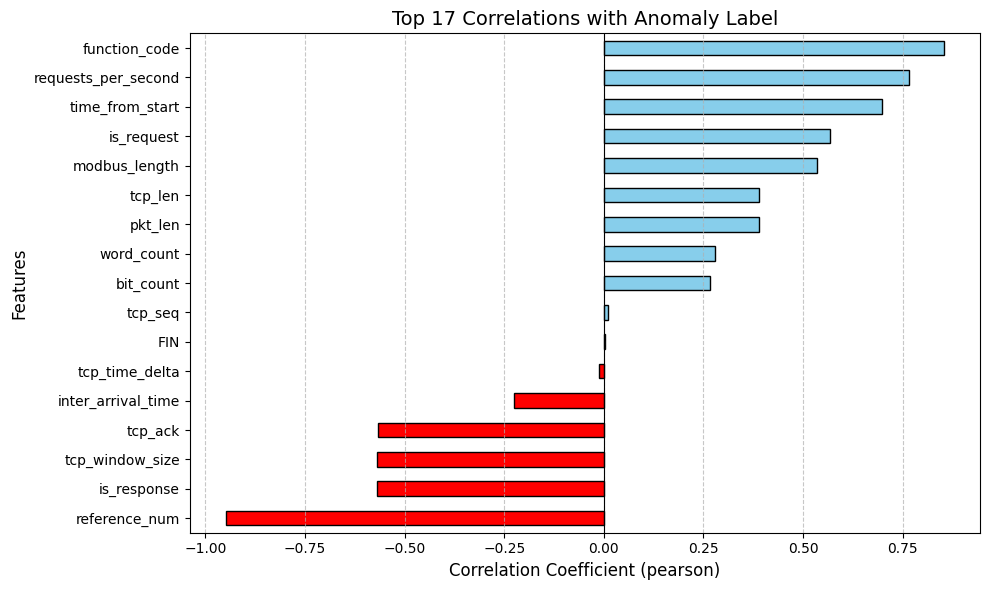

bit_count              0.981958
word_count             0.960702
function_code          0.920057
requests_per_second    0.864216
time_from_start        0.708941
is_request             0.568289
tcp_len                0.561418
pkt_len                0.561418
modbus_length          0.561415
tcp_seq                0.010707
FIN                    0.002823
inter_arrival_time    -0.498524
tcp_ack               -0.562758
is_response           -0.568289
tcp_window_size       -0.568289
tcp_time_delta        -0.836187
reference_num         -0.975464
tcp_retransmission          NaN
tcp_duplicate_ack           NaN
tcp_lost_segment            NaN
tcp_out_of_order            NaN
protocol_id                 NaN
byte_count                  NaN
exception_code              NaN
response_time               NaN
is_exception                NaN
SYN                         NaN
RST                         NaN
PSH                         NaN
ACK                         NaN
URG                         NaN
round_tr

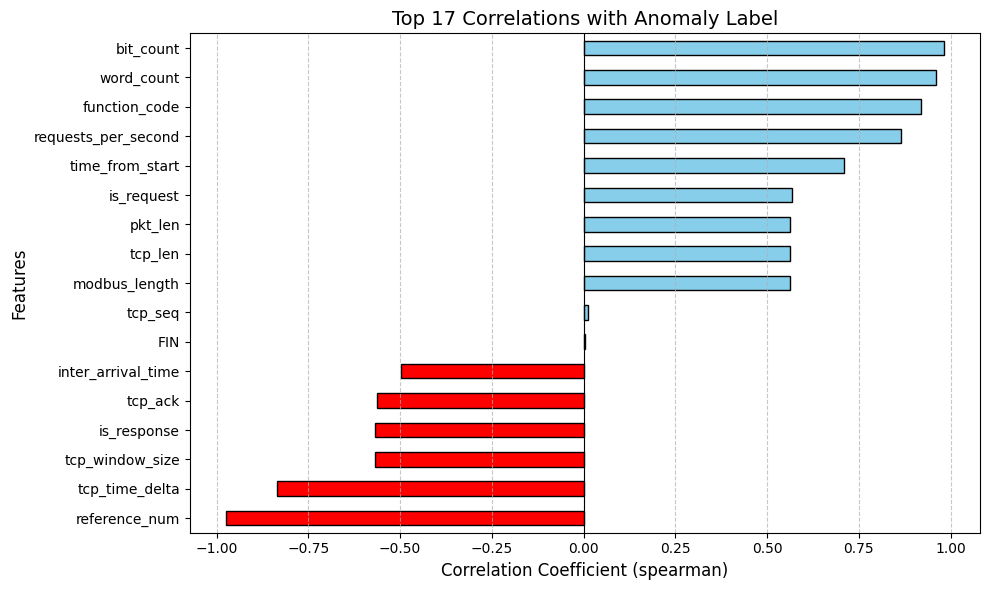

bit_count              0.981825
word_count             0.960532
function_code          0.844201
requests_per_second    0.723761
time_from_start        0.578850
is_request             0.568289
tcp_len                0.544962
pkt_len                0.544962
modbus_length          0.544960
tcp_seq                0.010706
FIN                    0.002823
inter_arrival_time    -0.407126
tcp_ack               -0.561955
is_response           -0.568289
tcp_window_size       -0.568289
tcp_time_delta        -0.685444
reference_num         -0.930293
tcp_retransmission          NaN
tcp_duplicate_ack           NaN
tcp_lost_segment            NaN
tcp_out_of_order            NaN
protocol_id                 NaN
byte_count                  NaN
exception_code              NaN
response_time               NaN
is_exception                NaN
SYN                         NaN
RST                         NaN
PSH                         NaN
ACK                         NaN
URG                         NaN
round_tr

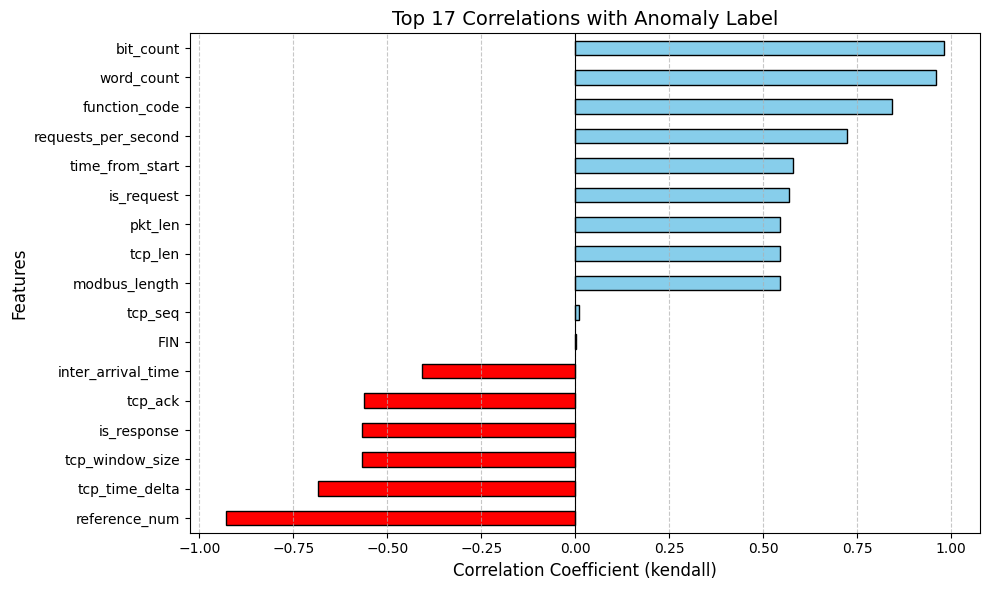

In [19]:
# Create numeric label FIRST (only if 'label' column exists)
if 'label' in benign_data.columns:
    benign_data['label_numeric'] = (benign_data['label'] == 'ANOMALY').astype(int)
if 'label' in external_attack_data.columns:
    external_attack_data['label_numeric'] = (external_attack_data['label'] == 'ANOMALY').astype(int)
if 'label' in compromised_scada_attack_data.columns:
    compromised_scada_attack_data['label_numeric'] = (compromised_scada_attack_data['label'] == 'ANOMALY').astype(int)

# Then drop columns
columns_to_drop = [
    'packet_number',
    'timestamp',
    'datetime',
    'src_ip',
    'dst_ip',
    'src_port',
    'dst_port',
    'tcp_stream',
    'transaction_id',
    'protocols',
    'unit_id',
    'tcp_flags',
    'function_name',
    'label',              # Drop original label after creating numeric version
    'request_frame',
    'response_frame',
]

benign_data = benign_data.drop(columns=columns_to_drop, errors='ignore')
external_attack_data = external_attack_data.drop(columns=columns_to_drop, errors='ignore')
compromised_scada_attack_data = compromised_scada_attack_data.drop(columns=columns_to_drop, errors='ignore')


# Compare all three
for method in ['pearson', 'spearman', 'kendall']:
    target_variable = 'label_numeric'

    # Calculate correlations 
    correlations = external_attack_data.corr(method=method)[target_variable].sort_values(ascending=False)
    correlations.drop(target_variable, inplace=True)  # Remove self-correlation
    print(correlations)

    # Get top features by absolute value
    number_of_features = 17
    top_feature_names = correlations.abs().sort_values(ascending=False).head(number_of_features).index

    # Get actual correlation values (not absolute)
    top_correlations = correlations[top_feature_names].sort_values(ascending=True)

    # Plot with color coding
    plt.figure(figsize=(10, 6))
    colors = ['red' if x < 0 else 'skyblue' for x in top_correlations]
    top_correlations.plot(kind='barh', color=colors, edgecolor='black')
    plt.title(f'Top {number_of_features} Correlations with Anomaly Label', fontsize=14)
    plt.xlabel(f'Correlation Coefficient ({method})', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)  # Add zero line
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [33]:
method = 'spearman'  # You can change this to 'pearson' or 'kendall' as needed
target_variable = 'label_numeric'

correlations = external_attack_data.corr(method=method)[target_variable].sort_values(ascending=False)
correlations.drop(target_variable, inplace=True)  # Remove self-correlation

 # Get top features by absolute value
number_of_features = 16
top_features = correlations.abs().sort_values(ascending=False).head(number_of_features).index
top_features = list(top_features)

print(top_features)
print("-" * len(str(top_features)))

print(f"Top {number_of_features} features by absolute {method} correlation with label_numeric:")
for feature in top_features:
    corr_value = correlations[feature]
    print(f"{feature}: {corr_value:.4f}")

['bit_count', 'reference_num', 'word_count', 'function_code', 'requests_per_second', 'tcp_time_delta', 'time_from_start', 'is_request', 'is_response', 'tcp_window_size', 'tcp_ack', 'tcp_len', 'pkt_len', 'modbus_length', 'inter_arrival_time', 'tcp_seq']
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Top 16 features by absolute spearman correlation with label_numeric:
bit_count: 0.9820
reference_num: -0.9755
word_count: 0.9607
function_code: 0.9201
requests_per_second: 0.8642
tcp_time_delta: -0.8362
time_from_start: 0.7089
is_request: 0.5683
is_response: -0.5683
tcp_window_size: -0.5683
tcp_ack: -0.5628
tcp_len: 0.5614
pkt_len: 0.5614
modbus_length: 0.5614
inter_arrival_time: -0.4985
tcp_seq: 0.0107
